In [1]:
import pandas as pd
import numpy as np
import time
import os
import warnings
import gc # Garbage collector

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # Meta-learner example
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# CatBoost
from catboost import CatBoostClassifier

# PyTorch & Transformers (for BERT)
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

# Optuna (for HPO)
import optuna

In [41]:
# --- Configuration ---
# File Path
DATA_FILE_PATH = r'D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv' # Use raw string

# General Settings
TARGET_COLUMN = 'loan_status'
RANDOM_STATE = 42
N_SPLITS_STACKING = 5 # Number of folds for stacking CV
N_TRIALS_HPO = 20 # Number of Optuna trials (adjust based on time/resources) - Keep low for demo

# Preprocessing & Feature Engineering
TEXT_COLUMN = 'text_representation' # Name for the generated text column

# --- Base Model Specific Config ---
# RF HPO Search Space (Example)
RF_HPO_PARAMS = {
    'n_estimators': (50, 300),
    'max_depth': (5, 30),
    'min_samples_leaf': (2, 20),
    'min_samples_split': (2, 20)
}

# CatBoost HPO Search Space (Example)
CATBOOST_HPO_PARAMS = {
    'iterations': (300, 1500),
    'learning_rate': (0.01, 0.2),
    'depth': (4, 10),
    'l2_leaf_reg': (1e-3, 10.0),
    'border_count': [32, 64, 128, 255]
}
CATBOOST_GPU = torch.cuda.is_available() # Use GPU for CatBoost if available

# BERT Settings (Using fixed params for stacking loop due to HPO cost)
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LENGTH = 128
BERT_BATCH_SIZE = 32 # Adjust based on GPU memory
BERT_EPOCHS = 3 # Fewer epochs for faster stacking loop training
BERT_LEARNING_RATE = 2e-5 # A common starting point

# BERT HPO Search Space (Example - VERY EXPENSIVE TO RUN)
BERT_HPO_PARAMS = {
    'learning_rate': (1e-5, 5e-5),
    'epochs': (2, 5) # Keep epochs low for HPO
}
RUN_BERT_HPO = False # Set to True to run BERT HPO (takes a long time!)

# Meta-Learner
# META_LEARNER = LogisticRegression(random_state=RANDOM_STATE, C=1.0, solver='liblinear') # Example meta-learner
import lightgbm as lgb
META_LEARNER = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.05)
# import xgboost as xgb
# META_LEARNER = xgb.XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss')
# from sklearn.svm import SVC
# META_LEARNER = SVC(probability=True, random_state=RANDOM_STATE) # probability=True 以便能用 predict_proba
# from sklearn.neural_network import MLPClassifier
# META_LEARNER = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=RANDOM_STATE, early_stopping=True)

# --- Helper Functions ---

def clean_data(df):
    """Applies initial cleaning steps."""
    print("处理缺失值...")
    for col in df.columns:
        if df[col].isnull().any():
            # print(f"列 '{col}' 存在缺失值。") # Verbose
            if pd.api.types.is_numeric_dtype(df[col]):
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
            else:
                # Ensure consistency before filling NA
                df[col] = df[col].astype(str)
                df[col].fillna('missing', inplace=True)
    # Ensure all object columns are string
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str)

    print("处理潜在的极端值...")
    if 'person_age' in df.columns:
        df['person_age'] = df['person_age'].clip(upper=100)
    if 'person_emp_exp' in df.columns:
        df['person_emp_exp'] = df['person_emp_exp'].clip(upper=60)
    return df

def row_to_text(row):
    """Converts a DataFrame row to a text description for BERT."""
    parts = []
    for col_name, value in row.items():
        if col_name != TARGET_COLUMN and col_name != TEXT_COLUMN: # Exclude target and the text itself
            if pd.isna(value): value = 'missing' # Handle any remaining NaNs
            # Format value
            if isinstance(value, float): formatted_value = f"{value:.2f}"
            elif isinstance(value, int): formatted_value = str(value)
            else: formatted_value = str(value).lower().replace(' ', '_')
            # Format column name
            formatted_col = col_name.replace('_', ' ')
            parts.append(f"{formatted_col} is {formatted_value}")
    return ". ".join(parts) + "."

class BertLoanDataset(Dataset):
    """PyTorch Dataset for BERT."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_bert_epoch(model, data_loader, optimizer, device, scheduler):
    """Trains BERT for one epoch."""
    model.train()
    total_loss = 0
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        model.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(data_loader)

def eval_bert_model(model, data_loader, device):
    """Evaluates BERT model, returns predictions and labels."""
    model.eval()
    predictions = []
    actual_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            actual_labels.extend(labels.cpu().numpy())
    return np.array(predictions), np.array(actual_labels)

def predict_bert_proba(model, data_loader, device):
    """Predicts probabilities for the positive class using BERT."""
    model.eval()
    probabilities = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=1)
            # Get probability of the positive class (index 1)
            probabilities.extend(probs[:, 1].cpu().numpy())
    return np.array(probabilities)

In [3]:
# --- Main Script ---

# 1. Load Data
print("1. 加载数据...")
try:
    df = pd.read_csv(DATA_FILE_PATH)
except FileNotFoundError:
    print(f"错误：找不到文件 {DATA_FILE_PATH}")
    exit()

1. 加载数据...


In [4]:
# 2. Initial Cleaning & Feature Engineering
print("\n2. 数据清洗和特征工程...")
df = clean_data(df.copy())
print("   转换表格数据为文本...")
df[TEXT_COLUMN] = df.apply(row_to_text, axis=1)


2. 数据清洗和特征工程...
处理缺失值...
处理潜在的极端值...
   转换表格数据为文本...


In [5]:
# 3. Define Features and Target
print("\n3. 定义特征和目标变量...")
y = df[TARGET_COLUMN].values
X = df.drop(columns=[TARGET_COLUMN, TEXT_COLUMN]) # Features for RF/CatBoost
X_text = df[TEXT_COLUMN] # Text feature for BERT

# Identify feature types for RF/CatBoost preprocessor
categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
# Ensure 'previous_loan_defaults_on_file' (if exists and numerical) is treated as numerical
if 'previous_loan_defaults_on_file' in numerical_features and 'previous_loan_defaults_on_file' in categorical_features:
    categorical_features.remove('previous_loan_defaults_on_file')

print(f"   分类特征 (RF/CatBoost): {categorical_features}")
print(f"   数值特征 (RF/CatBoost): {numerical_features}")

# Get categorical feature indices for CatBoost
cat_features_indices = [X.columns.get_loc(col) for col in categorical_features]
print(f"   CatBoost 分类特征索引: {cat_features_indices}")


3. 定义特征和目标变量...
   分类特征 (RF/CatBoost): ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
   数值特征 (RF/CatBoost): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
   CatBoost 分类特征索引: [1, 2, 5, 7, 12]


In [6]:
# 4. Initial Train/Test Split (for final evaluation)
print("\n4. 划分训练集和最终测试集...")
X_train_full, X_test, y_train_full, y_test, X_text_train_full, X_text_test = train_test_split(
    X, y, X_text, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"   完整训练集大小: {len(X_train_full)}")
print(f"   最终测试集大小: {len(X_test)}")


4. 划分训练集和最终测试集...
   完整训练集大小: 36000
   最终测试集大小: 9000


In [7]:
# 5. Define Preprocessor for RF/CatBoost (fit later inside HPO/CV)
preprocessor_rf_cat = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    (StandardScaler(), numerical_features),
    remainder='passthrough'
)

In [8]:
# 6. Hyperparameter Optimization (using a validation split from train_full)
print("\n6. 基础模型超参数优化 (HPO)...")
# Split train_full further for HPO
X_train_hpo, X_val_hpo, y_train_hpo, y_val_hpo, X_text_train_hpo, X_text_val_hpo = train_test_split(
    X_train_full, y_train_full, X_text_train_full,
    test_size=0.25, # Use 25% of train_full for validation during HPO
    random_state=RANDOM_STATE,
    stratify=y_train_full
)


6. 基础模型超参数优化 (HPO)...


In [9]:
# --- 6.1 Random Forest HPO ---
print("\n   --- 6.1 随机森林 HPO ---")
def objective_rf(trial):
    # Define search space using trial object
    n_estimators = trial.suggest_int('n_estimators', RF_HPO_PARAMS['n_estimators'][0], RF_HPO_PARAMS['n_estimators'][1])
    max_depth = trial.suggest_int('max_depth', RF_HPO_PARAMS['max_depth'][0], RF_HPO_PARAMS['max_depth'][1])
    min_samples_leaf = trial.suggest_int('min_samples_leaf', RF_HPO_PARAMS['min_samples_leaf'][0], RF_HPO_PARAMS['min_samples_leaf'][1])
    min_samples_split = trial.suggest_int('min_samples_split', RF_HPO_PARAMS['min_samples_split'][0], RF_HPO_PARAMS['min_samples_split'][1])

    # Preprocess data for this trial
    preprocessor = make_column_transformer(
        (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        (StandardScaler(), numerical_features),
        remainder='passthrough'
    )
    X_train_hpo_processed = preprocessor.fit_transform(X_train_hpo)
    X_val_hpo_processed = preprocessor.transform(X_val_hpo)

    # Create and train model
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train_hpo_processed, y_train_hpo)
    preds = model.predict(X_val_hpo_processed)
    f1 = f1_score(y_val_hpo, preds) # Optimize for F1 score
    return f1

study_rf = optuna.create_study(direction='maximize', study_name='rf_hpo')
study_rf.optimize(objective_rf, n_trials=N_TRIALS_HPO)
best_params_rf = study_rf.best_params
print(f"   最佳 RF F1 (验证集): {study_rf.best_value:.4f}")
print(f"   最佳 RF 参数: {best_params_rf}")

[I 2025-04-13 18:26:00,965] A new study created in memory with name: rf_hpo
[I 2025-04-13 18:26:01,136] Trial 0 finished with value: 0.7922840369024322 and parameters: {'n_estimators': 50, 'max_depth': 11, 'min_samples_leaf': 14, 'min_samples_split': 3}. Best is trial 0 with value: 0.7922840369024322.



   --- 6.1 随机森林 HPO ---


[I 2025-04-13 18:26:01,751] Trial 1 finished with value: 0.8063284233496999 and parameters: {'n_estimators': 283, 'max_depth': 27, 'min_samples_leaf': 6, 'min_samples_split': 11}. Best is trial 1 with value: 0.8063284233496999.
[I 2025-04-13 18:26:01,919] Trial 2 finished with value: 0.800769442154438 and parameters: {'n_estimators': 54, 'max_depth': 17, 'min_samples_leaf': 8, 'min_samples_split': 7}. Best is trial 1 with value: 0.8063284233496999.
[I 2025-04-13 18:26:02,169] Trial 3 finished with value: 0.7822626492325184 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 18, 'min_samples_split': 18}. Best is trial 1 with value: 0.8063284233496999.
[I 2025-04-13 18:26:02,727] Trial 4 finished with value: 0.8079759628516798 and parameters: {'n_estimators': 271, 'max_depth': 19, 'min_samples_leaf': 5, 'min_samples_split': 2}. Best is trial 4 with value: 0.8079759628516798.
[I 2025-04-13 18:26:02,955] Trial 5 finished with value: 0.8041746772864597 and parameters: 

   最佳 RF F1 (验证集): 0.8100
   最佳 RF 参数: {'n_estimators': 236, 'max_depth': 24, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [10]:
# --- 6.2 CatBoost HPO ---
print("\n   --- 6.2 CatBoost HPO ---")
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', CATBOOST_HPO_PARAMS['iterations'][0], CATBOOST_HPO_PARAMS['iterations'][1]),
        'learning_rate': trial.suggest_float('learning_rate', CATBOOST_HPO_PARAMS['learning_rate'][0], CATBOOST_HPO_PARAMS['learning_rate'][1], log=True),
        'depth': trial.suggest_int('depth', CATBOOST_HPO_PARAMS['depth'][0], CATBOOST_HPO_PARAMS['depth'][1]),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', CATBOOST_HPO_PARAMS['l2_leaf_reg'][0], CATBOOST_HPO_PARAMS['l2_leaf_reg'][1], log=True),
        'border_count': trial.suggest_categorical('border_count', CATBOOST_HPO_PARAMS['border_count']),
        'objective': 'Logloss',
        'eval_metric': 'F1',
        'cat_features': cat_features_indices,
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'early_stopping_rounds': 50,
        'task_type': 'GPU' if CATBOOST_GPU else 'CPU'
    }
    model = CatBoostClassifier(**params)
    # CatBoost handles categorical features internally, no OHE/Scaling needed here
    model.fit(X_train_hpo, y_train_hpo,
              eval_set=[(X_val_hpo, y_val_hpo)],
              verbose=False)
    preds = model.predict(X_val_hpo)
    f1 = f1_score(y_val_hpo, preds)
    # Store best iteration if early stopping occurred
    trial.set_user_attr("best_iteration", model.get_best_iteration())
    return f1

study_catboost = optuna.create_study(direction='maximize', study_name='catboost_hpo')
study_catboost.optimize(objective_catboost, n_trials=N_TRIALS_HPO)
best_params_catboost = study_catboost.best_params
# Update iterations to best iteration if early stopping happened
best_iteration_catboost = study_catboost.best_trial.user_attrs.get("best_iteration")
if best_iteration_catboost:
    best_params_catboost['iterations'] = best_iteration_catboost

print(f"   最佳 CatBoost F1 (验证集): {study_catboost.best_value:.4f}")
print(f"   最佳 CatBoost 参数: {best_params_catboost}")

[I 2025-04-13 18:26:23,668] A new study created in memory with name: catboost_hpo



   --- 6.2 CatBoost HPO ---


[I 2025-04-13 18:26:34,731] Trial 0 finished with value: 0.8207214537564416 and parameters: {'iterations': 1471, 'learning_rate': 0.1271668404588237, 'depth': 6, 'l2_leaf_reg': 0.05005507281973118, 'border_count': 128}. Best is trial 0 with value: 0.8207214537564416.
[I 2025-04-13 18:27:00,399] Trial 1 finished with value: 0.8228325255788906 and parameters: {'iterations': 798, 'learning_rate': 0.17181185095668056, 'depth': 9, 'l2_leaf_reg': 0.18125065614065242, 'border_count': 128}. Best is trial 1 with value: 0.8228325255788906.
[I 2025-04-13 18:27:37,204] Trial 2 finished with value: 0.813467282106978 and parameters: {'iterations': 1006, 'learning_rate': 0.14739430265157968, 'depth': 10, 'l2_leaf_reg': 0.07251847921208336, 'border_count': 32}. Best is trial 1 with value: 0.8228325255788906.
[I 2025-04-13 18:27:49,183] Trial 3 finished with value: 0.8070844686648502 and parameters: {'iterations': 765, 'learning_rate': 0.0938533978799539, 'depth': 8, 'l2_leaf_reg': 0.0186041728168673, 

   最佳 CatBoost F1 (验证集): 0.8357
   最佳 CatBoost 参数: {'iterations': 445, 'learning_rate': 0.09173265308081938, 'depth': 9, 'l2_leaf_reg': 9.082146108022878, 'border_count': 255}


In [11]:
# --- 6.3 BERT HPO (Optional & Expensive) ---
best_params_bert = {'learning_rate': BERT_LEARNING_RATE, 'epochs': BERT_EPOCHS} # Use defaults if not running HPO
if RUN_BERT_HPO:
    print("\n   --- 6.3 BERT HPO (可能非常耗时) ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

    # Create datasets for HPO
    train_hpo_dataset = BertLoanDataset(X_text_train_hpo.tolist(), y_train_hpo, tokenizer, BERT_MAX_LENGTH)
    val_hpo_dataset = BertLoanDataset(X_text_val_hpo.tolist(), y_val_hpo, tokenizer, BERT_MAX_LENGTH)
    train_hpo_loader = DataLoader(train_hpo_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
    val_hpo_loader = DataLoader(val_hpo_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)

    def objective_bert(trial):
        gc.collect() # Try to free memory
        torch.cuda.empty_cache() # Try to free GPU memory

        lr = trial.suggest_float('learning_rate', BERT_HPO_PARAMS['learning_rate'][0], BERT_HPO_PARAMS['learning_rate'][1], log=True)
        epochs = trial.suggest_int('epochs', BERT_HPO_PARAMS['epochs'][0], BERT_HPO_PARAMS['epochs'][1])

        model_bert = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(device)
        optimizer = AdamW(model_bert.parameters(), lr=lr)
        total_steps = len(train_hpo_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

        print(f"    Trial {trial.number}: Training BERT with lr={lr:.2e}, epochs={epochs}")
        for epoch in range(epochs):
            train_bert_epoch(model_bert, train_hpo_loader, optimizer, device, scheduler)

        preds, labels = eval_bert_model(model_bert, val_hpo_loader, device)
        f1 = f1_score(labels, preds)

        # Clean up GPU memory
        del model_bert, optimizer, scheduler
        gc.collect()
        torch.cuda.empty_cache()

        return f1

    study_bert = optuna.create_study(direction='maximize', study_name='bert_hpo')
    # Use fewer trials for BERT HPO due to cost
    study_bert.optimize(objective_bert, n_trials=max(1, N_TRIALS_HPO // 4)) # Reduced trials
    best_params_bert = study_bert.best_params
    print(f"   最佳 BERT F1 (验证集): {study_bert.best_value:.4f}")
    print(f"   最佳 BERT 参数: {best_params_bert}")
else:
    print("\n   --- 6.3 BERT HPO 已跳过 ---")
    print(f"   使用默认 BERT 参数: {best_params_bert}")


   --- 6.3 BERT HPO 已跳过 ---
   使用默认 BERT 参数: {'learning_rate': 2e-05, 'epochs': 3}


In [12]:
# --- 7. Stacking Cross-Validation ---
print(f"\n7. 开始 Stacking {N_SPLITS_STACKING}-折交叉验证...")
start_time_stacking = time.time()

skf = StratifiedKFold(n_splits=N_SPLITS_STACKING, shuffle=True, random_state=RANDOM_STATE)

# Initialize OOF prediction arrays (for meta-learner training features)
oof_rf = np.zeros(len(X_train_full))
oof_catboost = np.zeros(len(X_train_full))
oof_bert = np.zeros(len(X_train_full))

# Initialize Test prediction arrays (averaged over folds, for meta-learner test features)
test_preds_rf_folds = np.zeros((len(X_test), N_SPLITS_STACKING))
test_preds_catboost_folds = np.zeros((len(X_test), N_SPLITS_STACKING))
test_preds_bert_folds = np.zeros((len(X_test), N_SPLITS_STACKING))

# BERT specific setup outside the loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print(f"   BERT 将在 {device} 上运行 Stacking CV...")

# Stacking CV Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n   --- Fold {fold + 1}/{N_SPLITS_STACKING} ---")
    fold_start_time = time.time()

    # --- Get fold data ---
    X_train_fold, X_val_fold = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_full[train_idx], y_train_full[val_idx]
    X_text_train_fold, X_text_val_fold = X_text_train_full.iloc[train_idx], X_text_train_full.iloc[val_idx]

    # --- 7.1 Random Forest Fold ---
    print("      训练 RF...")
    # Preprocess fold data
    preprocessor_fold = make_column_transformer(
        (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        (StandardScaler(), numerical_features),
        remainder='passthrough'
    )
    X_train_fold_rf_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_fold_rf_processed = preprocessor_fold.transform(X_val_fold)
    X_test_rf_processed = preprocessor_fold.transform(X_test) # Transform test set using fold's preprocessor

    model_rf_fold = RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE, n_jobs=-1)
    model_rf_fold.fit(X_train_fold_rf_processed, y_train_fold)
    oof_rf[val_idx] = model_rf_fold.predict_proba(X_val_fold_rf_processed)[:, 1] # Predict proba
    test_preds_rf_folds[:, fold] = model_rf_fold.predict_proba(X_test_rf_processed)[:, 1]
    print("      RF 训练和预测完成。")
    del model_rf_fold, X_train_fold_rf_processed, X_val_fold_rf_processed, X_test_rf_processed, preprocessor_fold
    gc.collect()

    # --- 7.2 CatBoost Fold ---
    print("      训练 CatBoost...")
    model_catboost_fold = CatBoostClassifier(
        **best_params_catboost, # Use best HPO params
        objective='Logloss', eval_metric='F1', cat_features=cat_features_indices,
        random_seed=RANDOM_STATE, verbose=False,
        task_type='GPU' if CATBOOST_GPU else 'CPU'
        # No early stopping here, use iterations from HPO
    )
    # CatBoost handles categoricals, use original fold data
    model_catboost_fold.fit(X_train_fold, y_train_fold)
    oof_catboost[val_idx] = model_catboost_fold.predict_proba(X_val_fold)[:, 1] # Predict proba
    test_preds_catboost_folds[:, fold] = model_catboost_fold.predict_proba(X_test)[:, 1]
    print("      CatBoost 训练和预测完成。")
    del model_catboost_fold
    gc.collect()

    # --- 7.3 BERT Fold ---
    print("      训练 BERT...")
    # Create datasets and dataloaders for the fold
    train_bert_fold_dataset = BertLoanDataset(X_text_train_fold.tolist(), y_train_fold, tokenizer, BERT_MAX_LENGTH)
    val_bert_fold_dataset = BertLoanDataset(X_text_val_fold.tolist(), y_val_fold, tokenizer, BERT_MAX_LENGTH)
    test_bert_dataset = BertLoanDataset(X_text_test.tolist(), [0]*len(X_text_test), tokenizer, BERT_MAX_LENGTH) # Dummy labels for test

    train_bert_fold_loader = DataLoader(train_bert_fold_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
    val_bert_fold_loader = DataLoader(val_bert_fold_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)
    test_bert_loader = DataLoader(test_bert_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)

    # Initialize model, optimizer, scheduler for the fold
    model_bert_fold = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(device)
    optimizer_bert_fold = AdamW(model_bert_fold.parameters(), lr=best_params_bert['learning_rate'])
    total_steps_fold = len(train_bert_fold_loader) * best_params_bert['epochs']
    scheduler_bert_fold = get_linear_schedule_with_warmup(optimizer_bert_fold, num_warmup_steps=0, num_training_steps=total_steps_fold)

    # Train BERT for the specified epochs
    for epoch in range(best_params_bert['epochs']):
        train_bert_epoch(model_bert_fold, train_bert_fold_loader, optimizer_bert_fold, device, scheduler_bert_fold)

    # Predict probabilities on validation and test sets
    oof_bert[val_idx] = predict_bert_proba(model_bert_fold, val_bert_fold_loader, device)
    test_preds_bert_folds[:, fold] = predict_bert_proba(model_bert_fold, test_bert_loader, device)
    print("      BERT 训练和预测完成。")

    # Clean up GPU memory
    del model_bert_fold, optimizer_bert_fold, scheduler_bert_fold
    del train_bert_fold_dataset, val_bert_fold_dataset, test_bert_dataset
    del train_bert_fold_loader, val_bert_fold_loader, test_bert_loader
    gc.collect()
    torch.cuda.empty_cache()

    fold_end_time = time.time()
    print(f"   --- Fold {fold + 1} 耗时: {fold_end_time - fold_start_time:.2f} 秒 ---")


# Average test predictions across folds
test_preds_rf = np.mean(test_preds_rf_folds, axis=1)
test_preds_catboost = np.mean(test_preds_catboost_folds, axis=1)
test_preds_bert = np.mean(test_preds_bert_folds, axis=1)

stacking_time = time.time() - start_time_stacking
print(f"\nStacking CV 完成！总耗时: {stacking_time:.2f} 秒")


7. 开始 Stacking 5-折交叉验证...
   BERT 将在 cuda 上运行 Stacking CV...

   --- Fold 1/5 ---
      训练 RF...
      RF 训练和预测完成。
      训练 CatBoost...
      CatBoost 训练和预测完成。
      训练 BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


      BERT 训练和预测完成。
   --- Fold 1 耗时: 504.36 秒 ---

   --- Fold 2/5 ---
      训练 RF...
      RF 训练和预测完成。
      训练 CatBoost...
      CatBoost 训练和预测完成。
      训练 BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


      BERT 训练和预测完成。
   --- Fold 2 耗时: 494.88 秒 ---

   --- Fold 3/5 ---
      训练 RF...
      RF 训练和预测完成。
      训练 CatBoost...
      CatBoost 训练和预测完成。
      训练 BERT...


...

      BERT 训练和预测完成。
   --- Fold 3 耗时: 499.46 秒 ---

   --- Fold 4/5 ---
      训练 RF...
      RF 训练和预测完成。
      训练 CatBoost...
      CatBoost 训练和预测完成。
      训练 BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


      BERT 训练和预测完成。
   --- Fold 4 耗时: 498.75 秒 ---

   --- Fold 5/5 ---
      训练 RF...
      RF 训练和预测完成。
      训练 CatBoost...
      CatBoost 训练和预测完成。
      训练 BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


      BERT 训练和预测完成。
   --- Fold 5 耗时: 498.77 秒 ---

Stacking CV 完成！总耗时: 2496.69 秒


In [42]:
# --- 8. Train Meta-Learner ---
print("\n8. 训练元学习器 (Meta-Learner)...")

# Create training features for meta-learner from OOF predictions
X_meta_train = np.column_stack((oof_rf, oof_catboost, oof_bert))
# Create test features for meta-learner from averaged test predictions
X_meta_test = np.column_stack((test_preds_rf, test_preds_catboost, test_preds_bert))

print(f"   元学习器训练特征维度: {X_meta_train.shape}")
print(f"   元学习器测试特征维度: {X_meta_test.shape}")

# Train the meta-learner
META_LEARNER.fit(X_meta_train, y_train_full)
print("   元学习器训练完成。")


8. 训练元学习器 (Meta-Learner)...
   元学习器训练特征维度: (36000, 3)
   元学习器测试特征维度: (9000, 3)
[LightGBM] [Info] Number of positive: 8000, number of negative: 28000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763
   元学习器训练完成。



9. 在最终测试集上进行预测和评估...

--- Stacking 模型最终分类报告 (测试集) ---
                      precision    recall  f1-score   support

    Normal Customers       0.94      0.97      0.96      7000
Defaulting Customers       0.90      0.80      0.85      2000

            accuracy                           0.94      9000
           macro avg       0.92      0.89      0.90      9000
        weighted avg       0.93      0.94      0.93      9000


--- Stacking 模型最终混淆矩阵 (测试集) ---
[[6824  176]
 [ 402 1598]]


c:\Users\wjw20\miniconda3\envs\IS6941\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


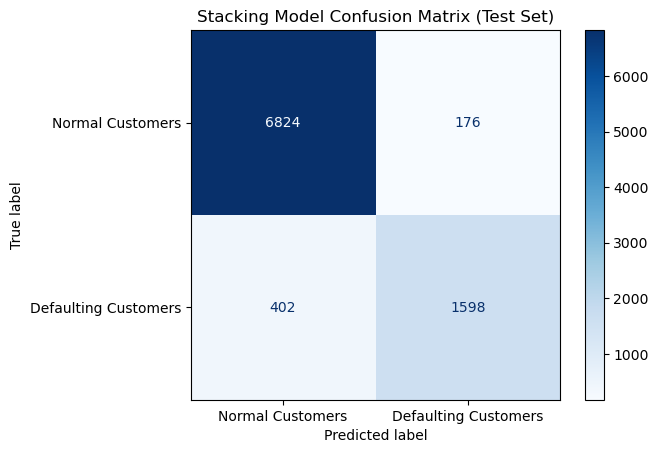


--- 脚本执行完毕 ---


In [43]:
# --- 9. Final Prediction and Evaluation ---
print("\n9. 在最终测试集上进行预测和评估...")

# Predict using the trained meta-learner
final_predictions_proba = META_LEARNER.predict_proba(X_meta_test)[:, 1]
# Convert probabilities to class labels (using 0.5 threshold)
final_predictions = (final_predictions_proba > 0.5).astype(int)

print("\n--- Stacking 模型最终分类报告 (测试集) ---")
report = classification_report(y_test, final_predictions, target_names=['Normal Customers', 'Defaulting Customers'])
print(report)

print("\n--- Stacking 模型最终混淆矩阵 (测试集) ---")
cm = confusion_matrix(y_test, final_predictions)
print(cm)

# 可视化混淆矩阵
try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal Customers', 'Defaulting Customers'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Stacking Model Confusion Matrix (Test Set)')
    plt.show()
except Exception as e:
    print(f"\n无法显示混淆矩阵图: {e}")

print("\n--- 脚本执行完毕 ---")